# Convolution Animation

* For the two defined functions, compute $𝑓_1\star 𝑓_2$  and  $𝑓_2\star 𝑓_1$ 
* Store in animation_topic5_1a_1.mp4 and animation_topic5_1a_2.mp4

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Course utilities (do not modify this cell)        
import sys
import os
base_path = os.path.expanduser("~/Documents/GitHub/Signals_and_Systems")
sys.path.insert(0, base_path)
sys.path.insert(0, os.path.join(base_path, "courseutils"))

import basic_material as bm
print("Basic Material version:", bm.__version__)
bm.setup_environment()


Basic Material version: 16.002-0.1


In [3]:
colors = bm.get_colors()
import numpy as np
import scipy
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredText
import sympy as sp
from sympy import Symbol, oo, integrate, Piecewise, Heaviside, DiracDelta, exp, I, pi, simplify

from ipywidgets import interactive
from IPython.display import HTML


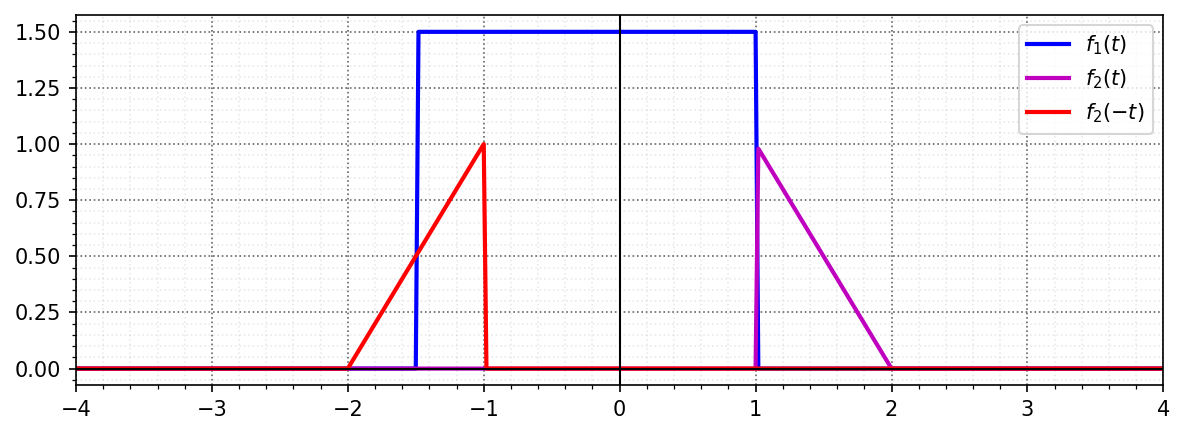

In [4]:
T = 6    # the time range we are interested in
t = np.arange(-T, T, 1/50)  # the time samples

f1 = lambda t: 1.5 * (t < 1) * (t > -1.5)  
f2 = lambda t: (t < 2) * (t > 1) * (2-t)  

t0 = np.arange(-3,4, 0.5) # set of values for which we wil compute output 

fig = plt.figure(1,figsize=(8,3))
plt.plot(t, f1(t), 'b', linewidth=2, label=r'$f_1(t)$')
plt.plot(t, f2(t), 'm-', linewidth=2, label=r'$f_2(t)$')
plt.plot(t, f2(-t), 'r-', linewidth=2, label=r'$f_2(-t)$')
bm.nicegrid()
plt.xlim([-4, 4])
plt.legend(fontsize=10)
plt.show()

In [5]:
def showConvolution(t0, f1, f2):
    # Calculate the overall convolution result using Simpson integration
    convolution = np.zeros(len(t))
    for n, t_ in enumerate(t):
        prod = lambda tau: f1(tau) * f2(t_-tau)
        convolution[n] = scipy.integrate.simpson(prod(t), t)

    # Create the shifted and flipped function
    f_shift = lambda t: f2(t0-t)
    prod = lambda tau: f1(tau) * f2(t0-tau)

    # Plot the curves
    plt.gcf().clear()
    plt.subplot(211)
    plt.tight_layout() 
    plt.gca().set_ymargin(0.1) 
    plt.plot(t, f1(t), linewidth=2,label=r'$f_1(\tau)$')
    plt.plot(t, f_shift(t), 'm',linewidth=2, label=r'$f_2(t_0-\tau)$')
    plt.fill(t, prod(t), color='r', alpha=0.5, edgecolor='black', hatch='//') # il
    plt.plot(t, prod(t), 'r-', linewidth=2,label=r'$f_1(\tau)f_2(t_0-\tau)$')
    plt.grid(True); plt.xlabel(r'$\tau$'); plt.ylabel(r'$x(\tau)$') # il
    plt.xlim([-6, 4])
    plt.legend(fontsize=10) 
    if t0 < 0:
        plt.text(-5, 0.6, '$t_0=%.2f$' % t0, bbox=dict(fc='white')) # il
    else:
        plt.text(3, 0.6, '$t_0=%.2f$' % t0, bbox=dict(fc='white')) # il
    
    # plot the convolution curve
    plt.subplot(212)
    bbox=plt.gca().get_position()
    offset=-.03
    plt.gca().set_position([bbox.x0, bbox.y0 - 2.5*offset, bbox.x1-bbox.x0, bbox.y1 - 4*bbox.y0])
    plt.gca().set_ymargin(0.5) 
    plt.plot(t, convolution, linewidth=2, label='$(f_1*f_2)(t_0)$')
    # recalculate the value of the convolution integral at the current time-shift t0
    current_value = scipy.integrate.simpson(prod(t), t)
    plt.plot(t0, current_value, 'ro')  # plot the point
    plt.grid(True); plt.xlabel('$t_0$'); plt.ylabel('$(f_1*f_2)(t_0)$') 
    plt.legend(fontsize=10) 
    plt.xlim([-6, 4])
    #plt.draw() 

## $f_1$ convolved with $f_2$

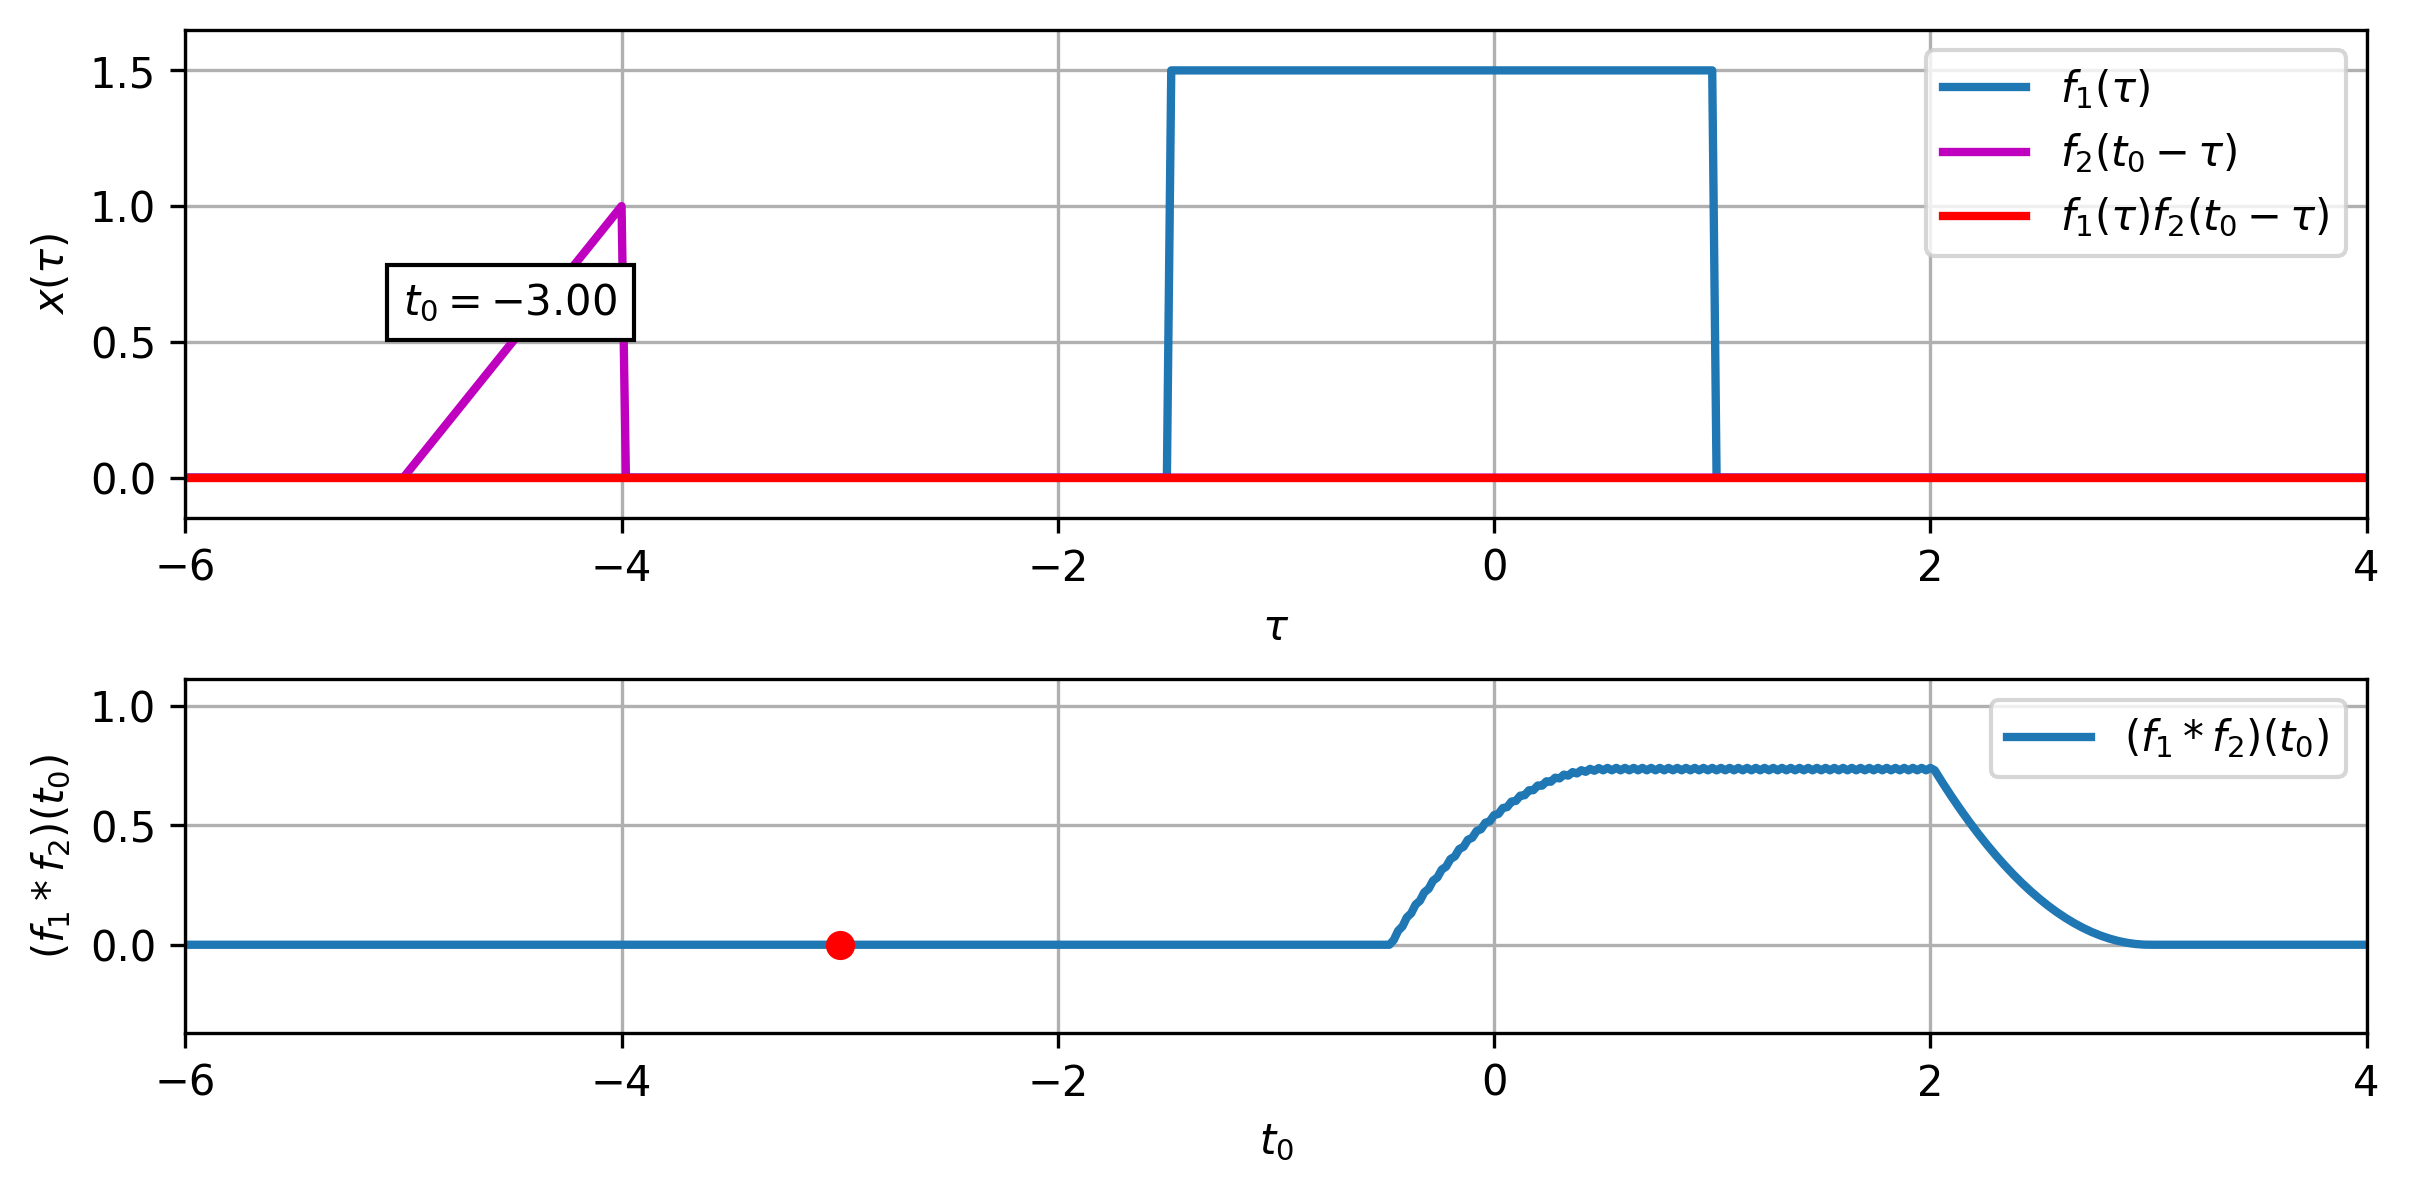

In [6]:
fig = plt.figure(2, figsize=(8, 4),dpi=300,constrained_layout = False)
anim = animation.FuncAnimation(fig, showConvolution, frames=t0, fargs=(f1,f2),interval=500,repeat=True,blit=False)
temp1 = anim.save('figs/animation_topic5_1a_1.mp4', fps=2) # fps = frames per second
HTML(anim.to_jshtml())

## $f_2$ convolved with $f_1$

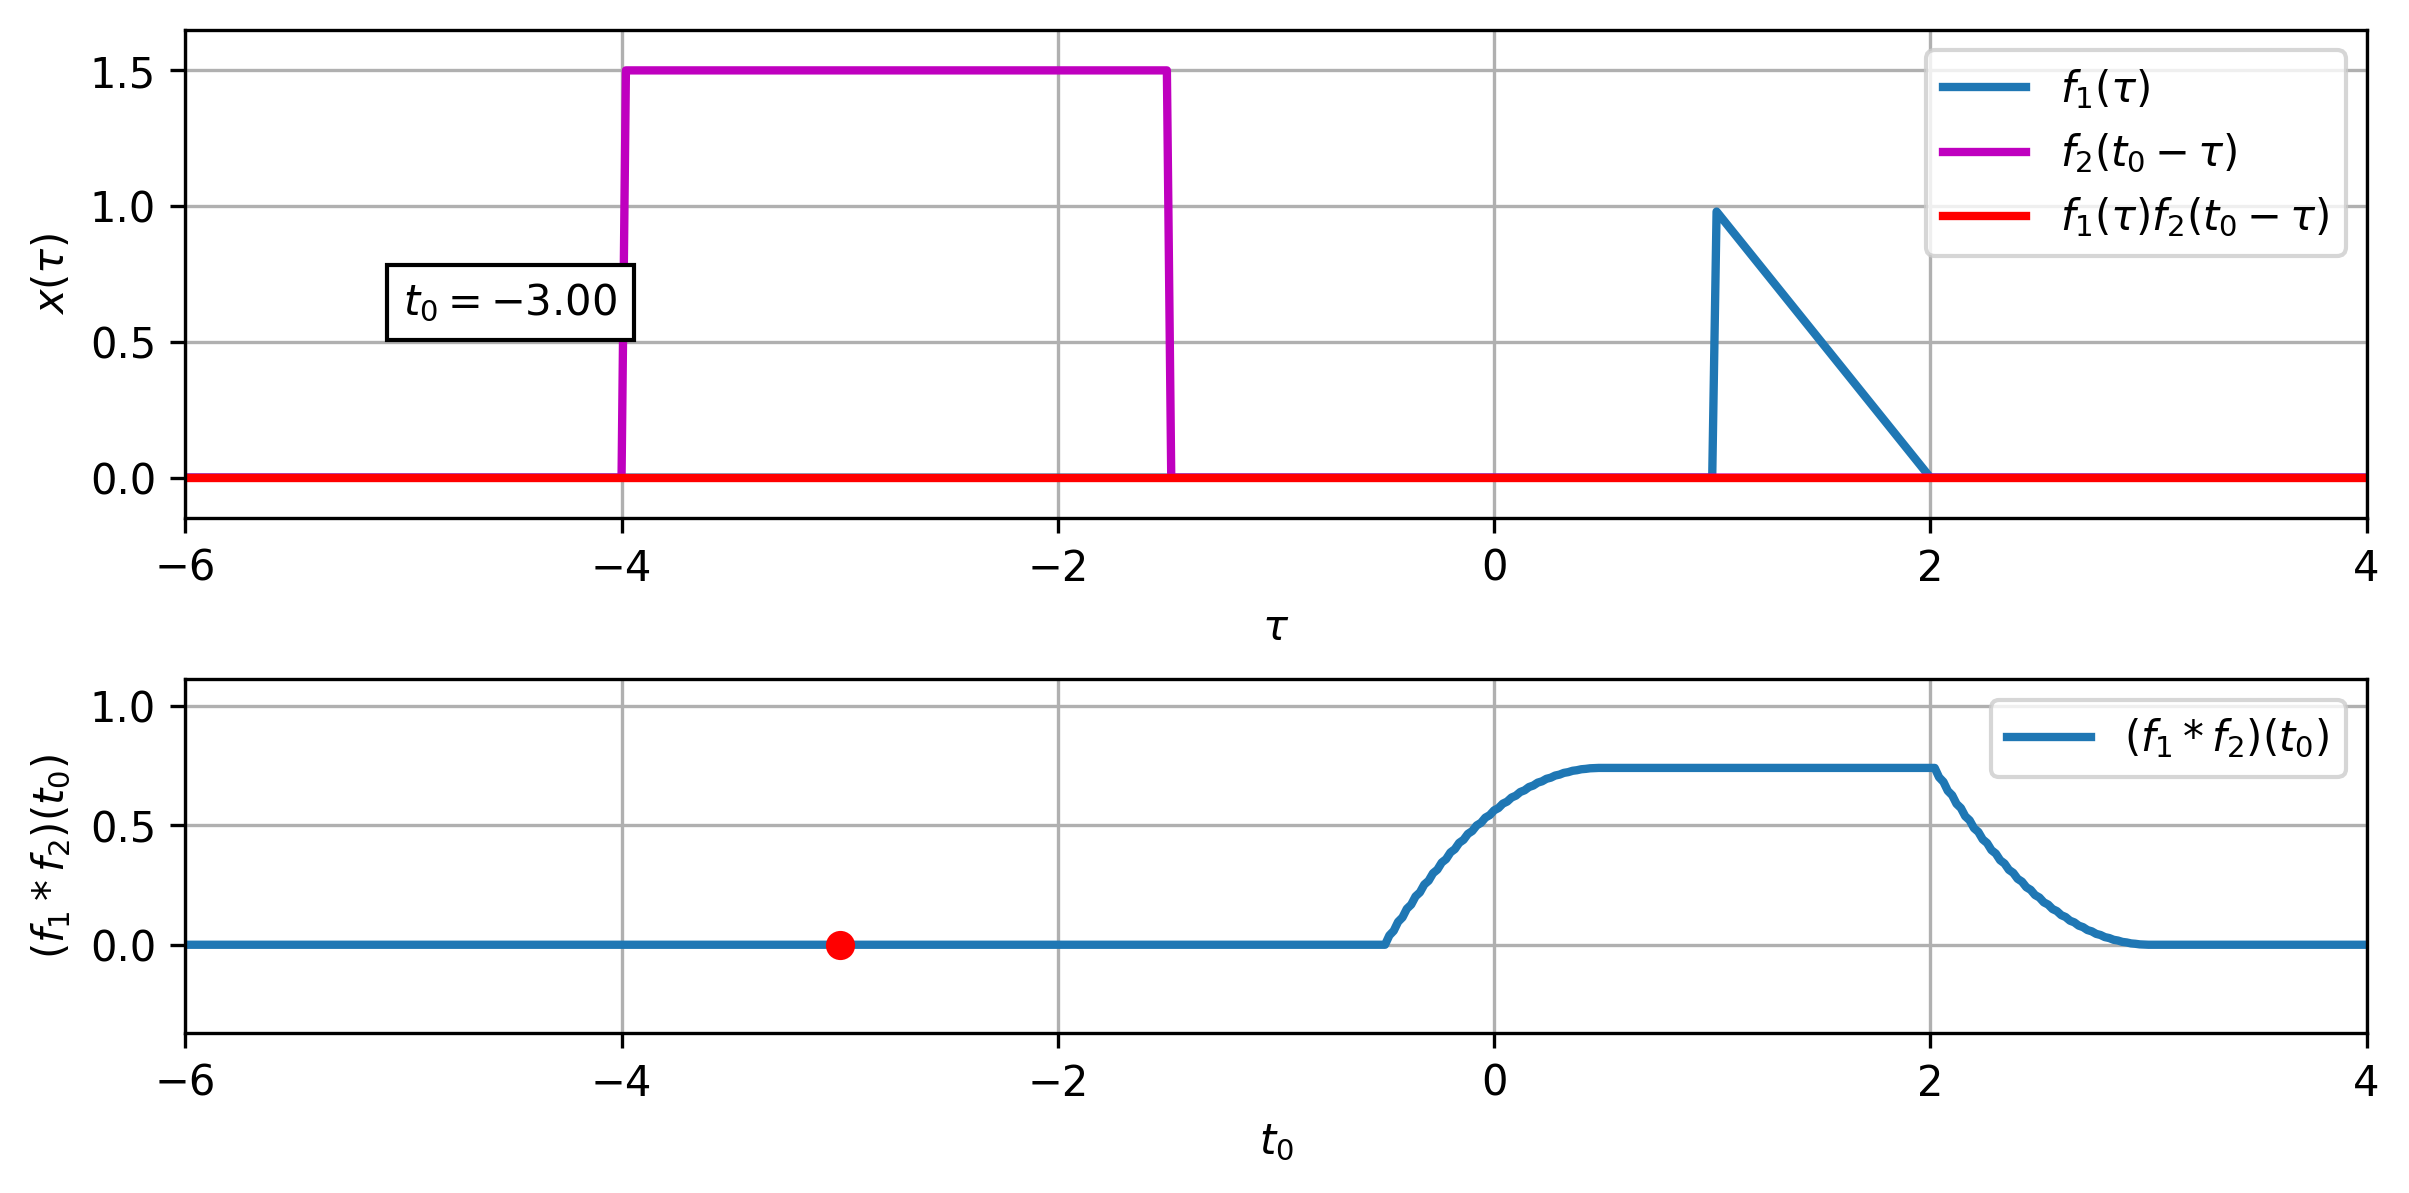

In [7]:
fig3 = plt.figure(3, figsize=(8, 4),dpi=300,constrained_layout = False)
anim = animation.FuncAnimation(fig3, showConvolution, frames=t0, fargs=(f2,f1),interval=500,repeat=True,blit=False)
temp2 = anim.save('figs/animation_topic5_1a_2.mp4', fps=2) # fps = frames per second
HTML(anim.to_jshtml())